In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
df_particles= pd.read_csv("/home/icantu24/Documents/corsario/dat_files/corsario_5000.csv")
df_shower = pd.read_csv("/home/icantu24/Documents/corsario/dat_files/shower_corsario_5000.csv")

In [3]:
GRID = 8

x_bins = np.linspace(df_particles["x"].min(), df_particles["x"].max(), GRID+1)
y_bins = np.linspace(df_particles["y"].min(), df_particles["y"].max(), GRID+1)

In [4]:
def build_tensor(shower_particles):

    tensor = np.zeros((GRID, GRID, 5))

    for i in range(GRID):
        for j in range(GRID):

            mask = (
                (shower_particles["x"] >= x_bins[i]) &
                (shower_particles["x"] < x_bins[i+1]) &
                (shower_particles["y"] >= y_bins[j]) &
                (shower_particles["y"] < y_bins[j+1])
            )

            cell = shower_particles[mask]

            if len(cell) > 0:

                e = cell["energy"].values
                t = cell["t"].values

                tensor[i,j,0] = len(cell)
                tensor[i,j,1] = e.sum()
                tensor[i,j,2] = e.mean()
                tensor[i,j,3] = np.nan_to_num(e.std())
                tensor[i,j,4] = t.mean()

    return tensor

In [5]:
X = []
y = []

for shower_id, group in df_particles.groupby("shower"):

    match = df_shower.loc[df_shower["event_no"] == int(shower_id)]

    if len(match) == 0:
        continue

    tensor = build_tensor(group)

    X.append(tensor)

    energy = match["total_energy"].values[0]
    y.append(energy)

X = np.array(X)
y = np.array(y)

print("Shape X:", X.shape)   # (N, 8, 8, 5)
print("Shape y:", y.shape)

Shape X: (4977, 8, 8, 5)
Shape y: (4977,)


In [6]:
X = (X - X.mean()) / (X.std() + 1e-8)
y = np.log1p(y)

In [7]:
class ShowerDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        grid = self.X[idx].reshape(-1)  # (320,)
        target = self.y[idx]

        return (
            torch.tensor(grid, dtype=torch.float32),
            torch.tensor([target], dtype=torch.float32)
        )

In [8]:
dataset = ShowerDataset(X, y)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

In [9]:
class ShowerMLP(nn.Module):

    def __init__(self, input_dim, depth, width):
        super().__init__()

        layers = []

        for i in range(depth):
            layers.append(
                nn.Linear(input_dim if i==0 else width, width)
            )
            layers.append(nn.ReLU())

        layers.append(nn.Linear(width, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [10]:
def train_model(model, train_loader, val_loader, epochs=50):

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    best_val_loss = float("inf")

    for epoch in range(epochs):

        # TRAIN
        model.train()
        train_loss = 0

        for grid, target in train_loader:

            pred = model(grid)
            loss = criterion(pred, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # VALIDATION
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for grid, target in val_loader:

                pred = model(grid)
                loss = criterion(pred, target)

                val_loss += loss.item()

        val_loss /= len(val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss

        print(f"Epoch {epoch+1} | Train {train_loss:.4f} | Val {val_loss:.4f}")

    return best_val_loss

In [ ]:
def train_model_full(model, train_loader, val_loader, epochs=30):

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # TRAIN
        model.train()
        train_loss = 0

        for x, y in train_loader:
            pred = model(x)
            loss = criterion(pred, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # VALIDATION
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for x, y in val_loader:
                pred = model(x)
                loss = criterion(pred, y)
                val_loss += loss.item()

        val_loss /= len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return train_losses, val_losses

In [ ]:
depths = [2,3,4,5,6]
widths = [8,16,32,64,128,256]

results = np.zeros((len(depths), len(widths)))

input_dim = GRID * GRID * 5  # 320

In [ ]:
histories = {}

for i, depth in enumerate(depths):
    for j, width in enumerate(widths):

        print(f"- depth={depth}, width={width}")

        model = ShowerMLP(input_dim, depth, width)

        train_l, val_l = train_model_full(
            model, train_loader, val_loader, epochs=30
        )

        histories[(depth, width)] = {
            "train": train_l,
            "val": val_l
        }


+ depth=1, width=2
Epoch 1 | Train 24.5638 | Val 12.9517
Epoch 2 | Train 5.7095 | Val 2.2300
Epoch 3 | Train 1.8877 | Val 1.5760
Epoch 4 | Train 1.4174 | Val 1.1784
Epoch 5 | Train 1.0708 | Val 0.8956
Epoch 6 | Train 0.8247 | Val 0.7091
Epoch 7 | Train 0.6632 | Val 0.5933
Epoch 8 | Train 0.5565 | Val 0.5269
Epoch 9 | Train 0.4934 | Val 0.4903
Epoch 10 | Train 0.4518 | Val 0.4652
Epoch 11 | Train 0.4225 | Val 0.4461
Epoch 12 | Train 0.4022 | Val 0.4335
Epoch 13 | Train 0.3888 | Val 0.4231
Epoch 14 | Train 0.3756 | Val 0.4159
Epoch 15 | Train 0.3684 | Val 0.4117
Epoch 16 | Train 0.3623 | Val 0.4055
Epoch 17 | Train 0.3561 | Val 0.4010
Epoch 18 | Train 0.3526 | Val 0.3978
Epoch 19 | Train 0.3491 | Val 0.3964
Epoch 20 | Train 0.3467 | Val 0.3922
Epoch 21 | Train 0.3429 | Val 0.3890
Epoch 22 | Train 0.3412 | Val 0.3871
Epoch 23 | Train 0.3423 | Val 0.3851
Epoch 24 | Train 0.3372 | Val 0.3826
Epoch 25 | Train 0.3342 | Val 0.3829
Epoch 26 | Train 0.3324 | Val 0.3813
Epoch 27 | Train 0.3324 |

In [ ]:
fig, axes = plt.subplots(
    len(depths),
    len(widths),
    figsize=(20, 12),
    sharex=True,
    sharey=True
)

for i, depth in enumerate(depths):
    for j, width in enumerate(widths):

        ax = axes[i, j]

        hist = histories[(depth, width)]

        ax.plot(hist["train"], label="T", linewidth=1)
        ax.plot(hist["val"], label="V", linewidth=1)

        ax.set_title(f"d={depth}, w={width}", fontsize=8)

        if i == len(depths)-1:
            ax.set_xlabel("Epoch")

        if j == 0:
            ax.set_ylabel("Loss")

plt.tight_layout()
plt.show()

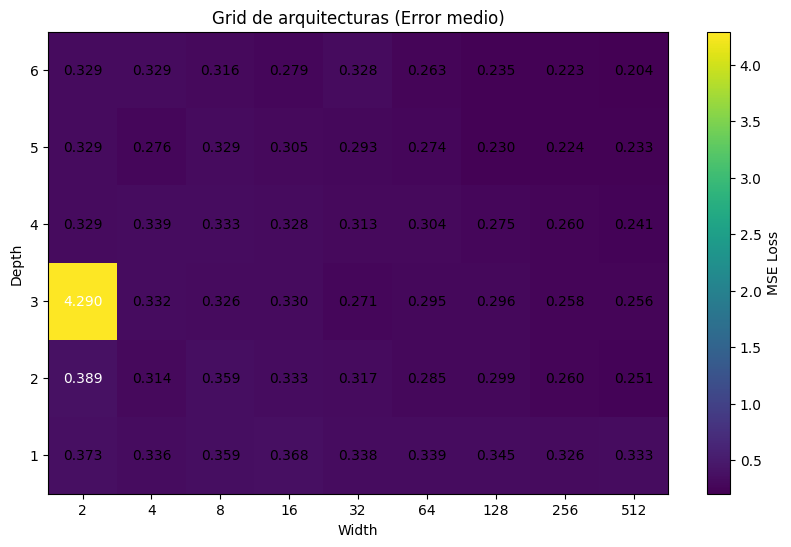

In [14]:
plt.figure(figsize=(10,6))

im = plt.imshow(results, aspect='auto', origin='lower')
plt.colorbar(im, label="MSE Loss")

plt.xticks(range(len(widths)), widths)
plt.yticks(range(len(depths)), depths)

plt.xlabel("Width")
plt.ylabel("Depth")

plt.title("Grid de arquitecturas (Error medio)")

# Agregar números en cada celda
for i in range(len(depths)):
    for j in range(len(widths)):
        plt.text(
            j, i,
            f"{results[i, j]:.3f}",
            ha='center',
            va='center',
            color='white' if results[i, j] > results.mean() else 'black'
        )

plt.show()